# Demo 3 (PS): Embedding of Pose Segmentation Data

*Written and last updated July 19, 2025 by Sedona Ewbank, snewbank@stanford.edu*

The purpose of this demo is to demonstrate how to load pose segmentation data and visualize it in various ways.

In [1]:
import os
import sys
import importlib

#This block only important for running as script
#script_dir = os.path.dirname(os.path.abspath(__file__))
mariposa_dir = "/Users/snewbank/PycharmProjects/MARIPoSA"
utils_dir = os.path.join(mariposa_dir, 'utils')
sys.path.append(utils_dir)
sys.path.append(mariposa_dir)

#import utils
from utils import metadata, analyze, plot, simulate

importlib.reload(metadata)
importlib.reload(analyze)
importlib.reload(plot)
importlib.reload(simulate)

<module 'utils.simulate' from '/Users/snewbank/PycharmProjects/MARIPoSA/utils/simulate.py'>

In [2]:
demo_dir="/Users/snewbank/Behavior/MARIPoSA_demo_data/"
config=metadata.load_project(demo_dir+"250719_test/config_PS.yaml")
save=True
save_path = demo_dir+"demo_figures/"
if not os.path.exists(save_path):
    os.makedirs(save_path)

## 3.1: Embedding with PCA
We can first try embedding our data agnostic to the subgroups with principal components analysis (PCA). Here we can make use here of the scaling function of module_usage and module_transitions - each can be scaled to unit variance with zero mean across features with .scale(), and scaling can be checked with .scaled. We can then use analyze.embed to embed and plot.plot_embeddings to visualize.

In [3]:
help(analyze.embed)

help(plot.plot_embeddings)

Help on function embed in module utils.analyze:

embed(module_feature_object, method='lda', n_components=2)
    Get dimensionally reduced space embeddings of the data with LDA or PCA
    
    :param module_feature_object: module feature object
    :param method: LDA or PCA; default LDA
    :param n_components: number of components
    :return:

Help on function plot_embeddings in module utils.plot:

plot_embeddings(module_feature_object, embeddings_object, figW=3, figH=3, cmap='viridis', title=None, legend=False, draw_ellipse=True, alt_legend=None)
    Plot embeddings
    
    :param module_feature_object: module feature object (ModuleUsage or ModuleTransitions) from analyze.get_module_{xx}
    :param embeddings_object: embeddings object (LDA or PCA) from analyze.embed
    :param figW: figure width
    :param figH: figure height
    :param cmap: matplotlib colormap
    :param title: title string, or None
    :param legend: True or False
    :return: fig



Is module usage scaled? False
Is module usage scaled now?? True
Ellipse only drawn for embeddings_object of class LDA, not <class 'sklearn.decomposition._pca.PCA'>


Are module transitions scaled? False
Are module transitions scaled now?? True
Ellipse only drawn for embeddings_object of class LDA, not <class 'sklearn.decomposition._pca.PCA'>


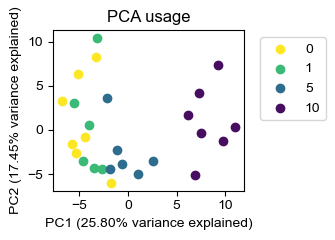

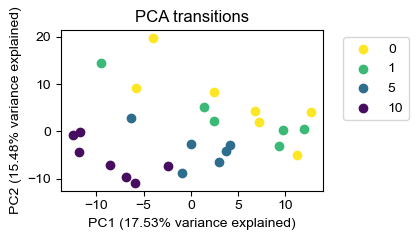

In [4]:
# Get and scale module usage
labels_df = analyze.get_module_labels(config, 0, 1200, subgroups = ["sal","k1","k5","k10"])
module_usage = analyze.get_module_usage(config, labels_df, binsize=300)
print(f"Is module usage scaled? {module_usage.scaled}")
module_usage = module_usage.scale()
print(f"Is module usage scaled now?? {module_usage.scaled}")

#Embed module usage
alt_legend={"sal":"0","k1":"1","k5":"5","k10":"10"}
emb = analyze.embed(module_usage,method="PCA",n_components=2)
fig = plot.plot_embeddings(module_usage, emb, figW=3.5, figH=2.5, cmap="viridis_r", title="PCA usage",legend=True,alt_legend=alt_legend)
if save:
    fig.savefig(save_path+"demo3-1_pca_embed_usage.png",dpi=300)
    
# Get and scale module transitions
module_transitions = analyze.get_module_transitions(config, labels_df)
print(f"Are module transitions scaled? {module_transitions.scaled}")
module_transitions = module_transitions.scale()
print(f"Are module transitions scaled now?? {module_transitions.scaled}")
    
# Embed module transitions
emb = analyze.embed(module_transitions,method="PCA",n_components=2)
fig = plot.plot_embeddings(module_transitions, emb, figW=3.5, figH=2.5, cmap="viridis_r", title="PCA transitions",legend=True,alt_legend=alt_legend)
if save:
    fig.savefig(save_path+"demo3-1_pca_embed_tx.png",dpi=300)

## 3.2: Embedding with LDA 
We can also embed based on class comparison (maximizing between-class distance and minimizing within-class distance) using linear discriminant analysis (LDA). Here again we make use of analyze.embed to embed and plot.plot_embeddings to visualize.

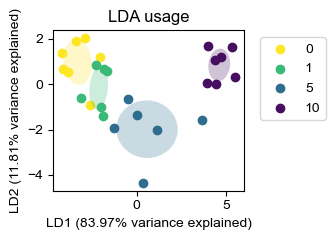

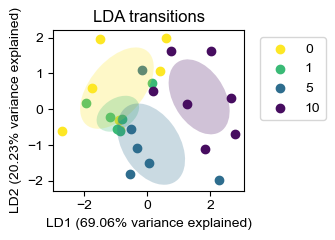

In [5]:
emb = analyze.embed(module_usage,method="LDA",n_components=2)
fig = plot.plot_embeddings(module_usage, emb, figW=3.5, figH=2.5, cmap="viridis_r", title="LDA usage",legend=True,draw_ellipse=True,alt_legend=alt_legend)
if save:
    fig.savefig(save_path+"demo3-2_lda_embed_usage.png",dpi=300)

emb = analyze.embed(module_transitions,method="LDA",n_components=2)
fig = plot.plot_embeddings(module_transitions, emb, figW=3.5, figH=2.5, cmap="viridis_r", title="LDA transitions",legend=True,draw_ellipse=True,alt_legend=alt_legend)
if save:
    fig.savefig(save_path+"demo3-2_lda_embed_tx.png",dpi=300)